##### DOWNLOAD CÁC THƯ VIỆN CẦN THIẾT
pip install pandas scikit-learn numpy networkx matplotlib python-louvain igraph leidenalg seaborn openpyxl

In [20]:
"""TIỀN XỬ LÍ DỮ LIỆU"""
import pandas as pd

# Đọc và xem dữ liệu
df = pd.read_excel('student_lifestyle_100k.xlsx')

# Tổng quan dữ liệu
print("Tổng quan dữ liệu:")
print(f"- Số dòng, số cột: {df.shape}")
print("- Cấu trúc dữ liệu:")
print(df.info())

# Chuẩn hóa tên cột
df.columns = (
    df.columns.str.strip()
              .str.lower()
              .str.replace(' ', '_')
              .str.replace(r'[^a-zA-Z0-9_]', '', regex=True)
)

print("\n- Tên cột sau khi chuẩn hóa:")
print(df.columns)

# Chuyển đổi dữ liệu sang dạng số
# Gender: Male = 1, Female = 0
if 'gender' in df.columns:
    df['gender'] = df['gender'].map({
        'Male': 1,
        'Female': 0
    })

# Depression: TRUE = 1, FALSE = 0
if 'depression' in df.columns:
    df['depression'] = (
        df['depression']
        .astype(str)
        .str.upper()
        .map({
            'TRUE': 1,
            'FALSE': 0
        })
    )

# Loại bỏ dữ liệu trùng lặp
duplicate_count = df.duplicated().sum()
print(f"\n- Số dòng trùng lặp: {duplicate_count}")

df_cleaned = df.drop_duplicates().copy()
print("- Kích thước sau khi loại bỏ trùng lặp:", df_cleaned.shape)

# Lưu dữ thành file với các kích thước khác nhau để thực nghiệm
def save_samples(df, sizes, prefix="student_lifestyle"):
    for n in sizes:
        # Kiểm tra kích thước hợp lệ
        if n <= len(df):
            sample_df = (
                df.sample(
                    n=n,
                    random_state=42
                )
                .reset_index(drop=True)
            )
            sample_df.to_excel(
                f"{prefix}_{n}.xlsx",
                index=False
            )
            print(f"Đã lưu: {prefix}_{n}.xlsx")
        else:
            print(f"Vượt quá kích thước dữ liệu")

# Lưu các mẫu dùng để thực nghiệm
# save_samples(df_cleaned, [200, 500, 1000, 5000, 100000])

Tổng quan dữ liệu:
- Số dòng, số cột: (100000, 11)
- Cấu trúc dữ liệu:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 11 columns):
 #   Column              Non-Null Count   Dtype  
---  ------              --------------   -----  
 0   Student_ID          100000 non-null  int64  
 1   Age                 100000 non-null  int64  
 2   Gender              100000 non-null  object 
 3   Department          100000 non-null  object 
 4   CGPA                100000 non-null  float64
 5   Sleep_Duration      100000 non-null  float64
 6   Study_Hours         100000 non-null  float64
 7   Social_Media_Hours  100000 non-null  float64
 8   Physical_Activity   100000 non-null  int64  
 9   Stress_Level        100000 non-null  int64  
 10  Depression          100000 non-null  bool   
dtypes: bool(1), float64(4), int64(4), object(2)
memory usage: 7.7+ MB
None

- Tên cột sau khi chuẩn hóa:
Index(['student_id', 'age', 'gender', 'department', 'cgpa', 'sl

In [21]:
"""CHUẨN HÓA DỮ LIỆU"""
from sklearn.preprocessing import MinMaxScaler

# CONFIG
# Các thuộc tính được chọn dùng để biểu diễn dữ liệu
FEATURES = [
    'cgpa',
    'sleep_duration',
    'study_hours',
    'social_media_hours',
    'physical_activity',
    'stress_level'
]
# Kích thước các bộ dữ liệu dùng để thực nghiệm
SIZES = [200, 500, 1000, 5000, 100000]

# DATASETS là dictionary chứa:
# key   = kích thước dữ liệu
# value = tên file tương ứng
DATASETS = {
    n: f"student_lifestyle_{n}.xlsx"
    for n in SIZES
}

# Hàm load và chuẩn hóa dữ liệu
def load_and_scale(size, features=FEATURES):
    """
    Đọc dữ liệu từ file Excel và chuẩn hóa dữ liệu về khoảng [0, 1].

    Parameters:
        size (int): Kích thước bộ dữ liệu cần load.
        features (list): Danh sách các cột cần chuẩn hóa.

    Returns:
        ndarray: Dữ liệu sau khi chuẩn hóa bằng MinMaxScaler.
    """

    file_path = DATASETS[size]
    df = pd.read_excel(file_path)
    return MinMaxScaler().fit_transform(df[features])

# Kết quả chuẩn hóa
X_scale = load_and_scale(100000)
print(pd.DataFrame(X_scale, columns=FEATURES).head().to_string(index=False))


    cgpa  sleep_duration  study_hours  social_media_hours  physical_activity  stress_level
0.299180        0.222222     0.101562                0.32           0.093960         0.125
0.889344        0.466667     0.367188                0.31           0.060403         0.375
0.426230        0.477778     0.351562                0.32           0.469799         0.000
0.553279        0.411111     0.125000                0.30           0.818792         0.000
0.831967        0.411111     0.320312                0.36           0.060403         0.375


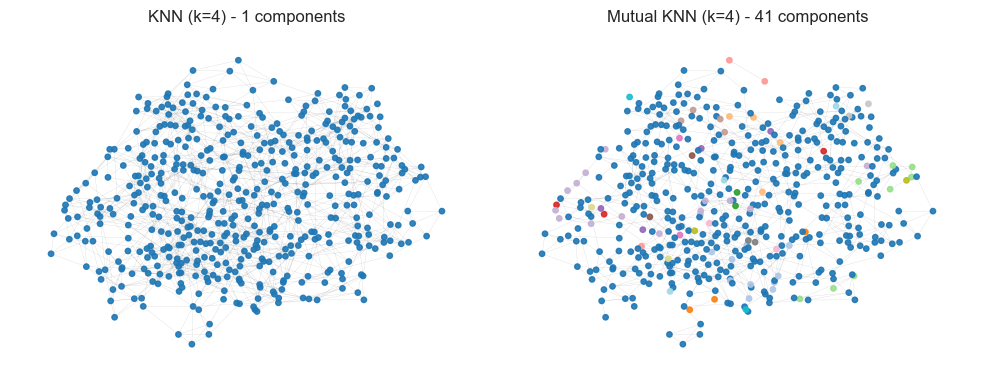

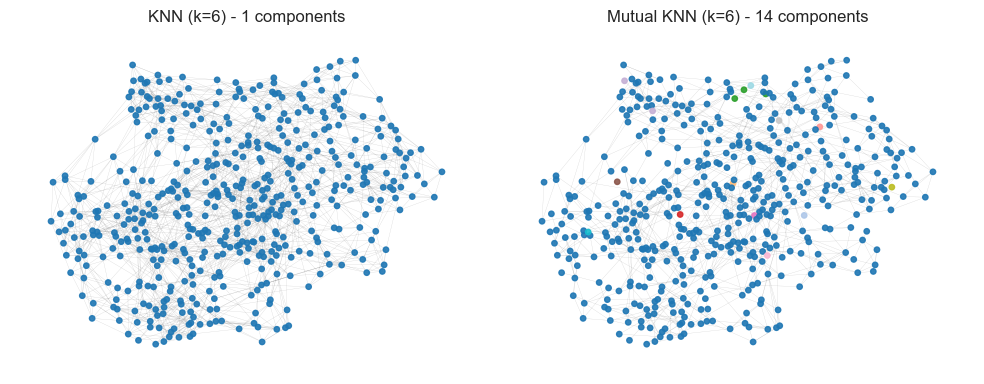

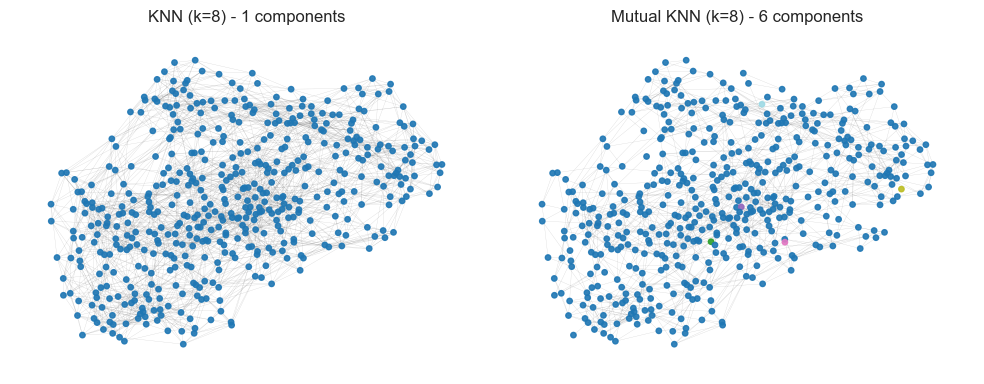

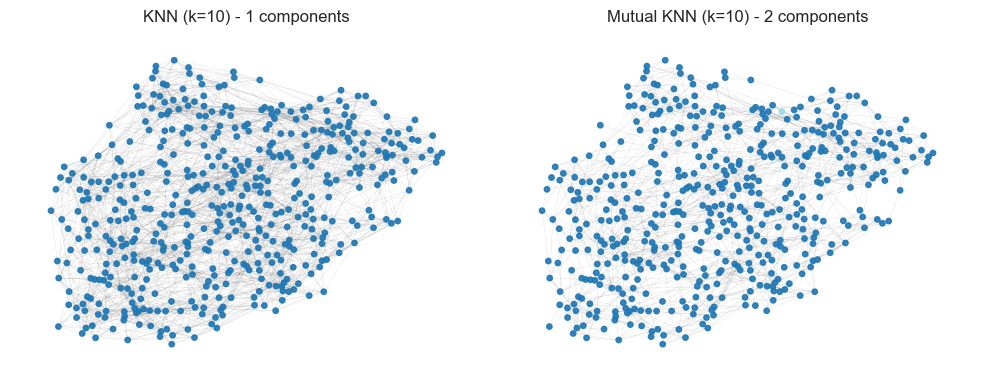

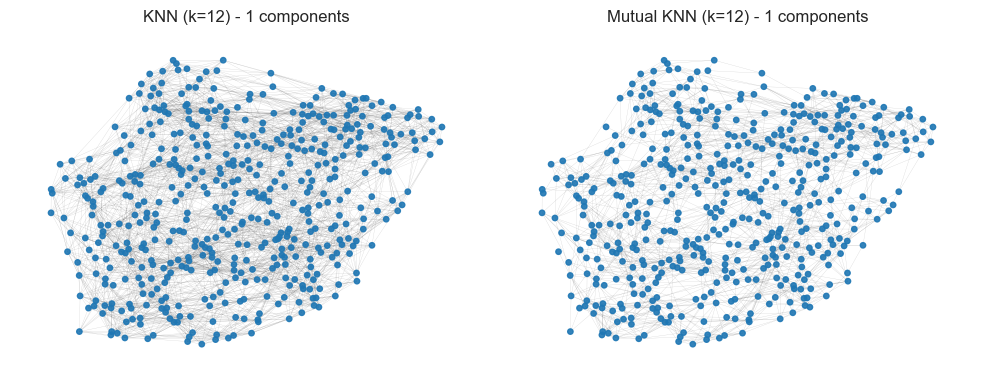


200 node


,k,mean_knn,mean_mutual,std_knn,std_mutual,max_knn,max_mutual,comp_knn,comp_mutual,density_knn,density_mutual
0,3,4.210000,1.790000,1.279023,0.972574,11,3,1,49,0.021156,0.008995
1,4,5.510000,2.490000,1.367443,1.260912,11,4,1,23,0.027688,0.012513
2,5,6.810000,3.190000,1.610559,1.401392,12,5,1,12,0.034221,0.016030
3,6,8.110000,3.890000,1.896813,1.678660,15,6,1,6,0.040754,0.019548
4,7,9.360000,4.640000,2.107226,1.854832,16,7,1,5,0.047035,0.023317
5,8,10.640000,5.360000,2.319569,2.135509,18,8,1,4,0.053467,0.026935
6,9,11.980000,6.020000,2.622899,2.340855,20,9,1,3,0.060201,0.030251
7,10,13.260000,6.740000,2.953371,2.492469,22,10,1,3,0.066633,0.033869



500 node


,k,mean_knn,mean_mutual,std_knn,std_mutual,max_knn,max_mutual,comp_knn,comp_mutual,density_knn,density_mutual
0,4,5.412000,2.588000,1.358770,1.217479,12,4,1,41,0.010846,0.005186
1,6,7.956000,4.044000,1.745298,1.594385,17,6,1,14,0.015944,0.008104
2,8,10.592000,5.408000,2.154422,1.931201,19,8,1,6,0.021226,0.010838
3,10,13.176000,6.824000,2.610943,2.321427,22,10,1,2,0.026405,0.013675
4,12,15.800000,8.200000,3.107410,2.698148,26,12,1,1,0.031663,0.016433
5,14,18.408000,9.592000,3.581834,3.094759,30,14,1,1,0.036890,0.019222
6,16,21.040000,10.960000,4.063791,3.476550,34,16,1,1,0.042164,0.021964
7,18,23.696000,12.304000,4.641938,3.888905,38,18,1,1,0.047487,0.024657



1000 node


,k,mean_knn,mean_mutual,std_knn,std_mutual,max_knn,max_mutual,comp_knn,comp_mutual,density_knn,density_mutual
0,4,5.294000,2.706000,1.196480,1.152200,12,4,1,65,0.005299,0.002709
1,6,7.866000,4.134000,1.550498,1.540144,15,6,1,23,0.007874,0.004138
2,8,10.492000,5.508000,1.973813,1.891015,18,8,1,7,0.010503,0.005514
3,10,13.092000,6.908000,2.360410,2.271461,24,10,1,3,0.013105,0.006915
4,13,17.032000,8.968000,3.027371,2.811223,31,13,1,2,0.017049,0.008977
5,15,19.590000,10.410000,3.447303,3.183693,33,15,1,1,0.019610,0.010420
6,18,23.546000,12.454000,4.134959,3.773842,39,18,1,1,0.023570,0.012466
7,20,26.210000,13.790000,4.656383,4.153541,43,20,1,1,0.026236,0.013804



5000 node


,k,mean_knn,mean_mutual,std_knn,std_mutual,max_knn,max_mutual,comp_knn,comp_mutual,density_knn,density_mutual
0,5,6.530000,3.470000,1.348592,1.284017,12,5,1,116,0.001306,0.000694
1,10,12.826000,7.174000,2.060613,2.134695,25,10,1,10,0.002566,0.001435
2,15,19.119600,10.880400,2.723398,3.002415,35,15,1,2,0.003825,0.002177
3,20,25.560800,14.439200,3.474925,3.902243,44,20,1,1,0.005113,0.002888
4,25,32.009200,17.990800,4.271430,4.830436,55,25,1,1,0.006403,0.003599
5,30,38.451200,21.548800,5.115469,5.765104,61,30,1,1,0.007692,0.004311
6,35,44.938400,25.061600,5.996449,6.685881,66,35,1,1,0.008989,0.005013
7,40,51.398800,28.601200,6.898359,7.631812,76,40,1,1,0.010282,0.005721


In [22]:
"""SO SÁNH K-NN VÀ MUTUAL K-NN"""

import numpy as np
import networkx as nx
import matplotlib.pyplot as plt
from sklearn.neighbors import kneighbors_graph

# Kích thước các dataset dùng để thực nghiệm nhằm mục đích so sánh K-NN và Mutual K-NN
EXPERIMENT_SIZES = [200, 500, 1000, 5000]

# Các giá trị k tương ứng với từng dataset dùng để so sánh sự khác nhau giữa K-NN và Mutual K-NN khi k thay đổi
K_VALUES = {
    200:  [3, 4, 5, 6, 7, 8, 9, 10],
    500:  [4, 6, 8, 10, 12, 14, 16, 18],
    1000: [4, 6, 8, 10, 13, 15, 18, 20],
    5000: [5, 10, 15, 20, 25, 30, 35, 40]
}

# Hàm xây dựng ma trận K-NN
def build_knn_matrix(X, k, metric='cosine'):
    """
    Tạo ma trận KNN similarity

    Parameters
    ----------
    X (ndarray): Dữ liệu đầu vào
    k (int): Số lượng láng giềng gần nhất
    metric (str): Độ đo khoảng cách
    """

    # kneighbors_graph(): Tạo graph KNN dưới dạng sparse matrix
    # mode='distance': Giá trị lưu trong ma trận là khoảng cách
    # metric='cosine': Dùng cosine distance để đo độ tương đồng
    # include_self=False: Không tính chính node đó là hàng xóm
    A = kneighbors_graph(
        X,
        n_neighbors=k,
        mode='distance',
        metric=metric,
        include_self=False
    ).tocsr()

    # Chuyển từ Distance -> Similarity
    # Cosine distance: càng nhỏ => càng giống nhau
    # Chuyển thành similarity: similarity = 1 - distance
    # Sau chuyển đổi: giá trị càng lớn => càng tương đồng
    A.data = 1 - A.data

    return A


# Hàm xây dựng đồ thị
def build_graphs(A):
    """
    Tạo KNN graph và Mutual KNN graph

    Parameters
    ----------
    A (sparse matrix): Ma trận similarity K-NN

    Returns
    -------
    tuple:
        - G_knn    : K-NN graph
        - G_mutual : Mutual K-NN graph
    """

    # Tạo K-NN graph từ sparse matrix
    G_knn = nx.from_scipy_sparse_array(A)

    # Chỉ giữ cạnh nếu 2 node là neighbor của nhau
    A_mutual = A.multiply(A.T)

    # Tạo Mutual K-NN graph
    G_mutual = nx.from_scipy_sparse_array(A_mutual)

    return G_knn, G_mutual


# Hàm tính metrics của graph
def compute_graph_metrics(G):
    """
    Tính metrics của graph

    Parameters
    ----------
    G (graph): Đồ thị cần phân tích

    Returns
    -------
    dict: Các metrics của graph
    """

    # Degree (bậc) của từng node
    degrees = np.array([d for _, d in G.degree()])

    return {
        "mean": degrees.mean(),
        "std": degrees.std(),
        "max": degrees.max(),
        "components": nx.number_connected_components(G),
        "density": nx.density(G)
    }


# Hàm đánh giá đồ thị
def evaluate_graphs(X, k):
    """
    Đánh giá graph với một giá trị k

    Parameters
    ----------
    X (ndarray): Dữ liệu đầu vào
    k (int): Số lượng láng giềng gần nhất

    Returns
    -------
    dict: Kết quả metrics của graph
    """

    # Tạo ma trận K-NN
    A = build_knn_matrix(X, k)

    # Tạo K-NN graph và Mutual K-NN graph
    G_knn, G_mutual = build_graphs(A)

    # Tính metrics cho từng graph
    knn_metrics = compute_graph_metrics(G_knn)
    mutual_metrics = compute_graph_metrics(G_mutual)

    return {
        "k": k,

        "mean_knn": knn_metrics["mean"],
        "mean_mutual": mutual_metrics["mean"],

        "std_knn": knn_metrics["std"],
        "std_mutual": mutual_metrics["std"],

        "max_knn": knn_metrics["max"],
        "max_mutual": mutual_metrics["max"],

        "comp_knn": knn_metrics["components"],
        "comp_mutual": mutual_metrics["components"],

        "density_knn": knn_metrics["density"],
        "density_mutual": mutual_metrics["density"]
    }


# Hàm chạy thực nghiệm
def run_experiment(X, k_list):
    """
    Chạy thực nghiệm với nhiều giá trị k

    Parameters
    ----------
    X (ndarray): Dữ liệu đầu vào
    k_list (list): Danh sách giá trị k

    Returns
    -------
    DataFrame: Bảng kết quả thực nghiệm
    """

    return pd.DataFrame([
        evaluate_graphs(X, k)
        for k in k_list
    ])


# Hàm hiển thị kết quả
def display_result(title, df, use_color=True):
    """
    Hiển thị kết quả

    Parameters
    ----------
    title (str): Tiêu đề bảng kết quả
    df (DataFrame): Dữ liệu kết quả
    use_color (bool): Có hiển thị màu hay không
    """

    print(f"\n{title}")
    try:
        if use_color:
            # Tô màu gradient cho DataFrame
            display(
                df.style.background_gradient(cmap="coolwarm")
            )
        else:
            display(df)

    except:
        print(df.round(4))


# Hàm gán màu theo connected component
def get_component_colors(G):
    """
    Gán màu theo connected component (thành phần liên thông)

    Parameters
    ----------
    G (graph): Đồ thị cần xử lý

    Returns
    -------
    tuple:
        - colors       : Danh sách màu node
        - n_components : Số connected component
    """

    # Lấy các connected component
    components = list(nx.connected_components(G))

    # Mapping node -> component id
    node_to_component = {
        node: comp_id
        for comp_id, component in enumerate(components)
        for node in component
    }

    # Danh sách màu của từng node
    colors = [
        node_to_component[node]
        for node in G.nodes()
    ]

    return colors, len(components)


# Hàm vẽ đồ thị
def draw_graph(G, pos, title):
    """
    Vẽ đồ thị

    Parameters
    ----------
    G (graph): Đồ thị cần vẽ
    pos (dict): Vị trí các node
    title (str): Tiêu đề graph
    """

    # Lấy màu node theo component
    colors, n_components = get_component_colors(G)

    # Vẽ node
    nx.draw_networkx_nodes(
        G,
        pos,
        node_color=colors,
        cmap=plt.cm.tab20,
        node_size=15,
        alpha=0.9
    )

    # Vẽ edge
    nx.draw_networkx_edges(
        G,
        pos,
        width=0.2,
        alpha=0.2
    )

    plt.title(f"{title} - {n_components} components")
    plt.axis('off')


# Hàm trực quan hóa K-NN và Mutual K-NN
def visualize_knn_vs_mutual(X, k_list):
    """
    So sánh trực quan KNN và Mutual KNN

    Parameters
    ----------
    X (ndarray): Dữ liệu đầu vào
    k_list (list): Danh sách giá trị k
    """

    for k in k_list:
        # Tạo ma trận K-NN
        A = build_knn_matrix(X, k)

        # Tạo đồ thị
        G_knn, G_mutual = build_graphs(A)

        # Tạo vị trí node
        pos = nx.spring_layout(
            G_knn,
            seed=42,
            k=0.15
        )

        plt.figure(figsize=(10, 4))

        # K-NN graph
        plt.subplot(1, 2, 1)
        draw_graph(
            G_knn,
            pos,
            f"KNN (k={k})"
        )

        # Mutual K-NN graph
        plt.subplot(1, 2, 2)
        draw_graph(
            G_mutual,
            pos,
            f"Mutual KNN (k={k})"
        )

        plt.tight_layout()
        plt.show()


# Chương trình chính

# Load dữ liệu chuẩn hóa
scaled_data = {
    size: load_and_scale(size)
    for size in EXPERIMENT_SIZES
}

# Trực quan hóa
X_500 = scaled_data[500]

# Các giá trị k dùng để trực quan hóa
k_visual = [4, 6, 8, 10, 12]

# So sánh trực quan K-NN và Mutual K-NN
visualize_knn_vs_mutual(
    X_500,
    k_visual
)

# Chạy thực nghiệm với từng dataset
results = {
    size: run_experiment(
        scaled_data[size],
        K_VALUES[size]
    )
    for size in EXPERIMENT_SIZES
}

# Hiển thị kết quả thực nghiệm
for size in EXPERIMENT_SIZES:
    display_result(
        f"{size} node",
        results[size]
    )

In [23]:
"""SO SÁNH CÁC THUẬT TOÁN PHÁT HIỆN CỘNG ĐỒNG"""

import time
from networkx.algorithms.community import (
    girvan_newman,
    label_propagation_communities
)
import community as community_louvain
import igraph as ig
import leidenalg

# Giá trị k được chọn sau thực nghiệm
BEST_K = {
    200: 10,
    500: 14
}


# Hàm xây dựng Mutual KNN graph
def build_mutual_graph(X, k):
    """
    Tạo Mutual KNN graph

    Parameters
    ----------
    X (ndarray): Dữ liệu đầu vào
    k (int): Số lượng láng giềng gần nhất

    Returns
    -------
    graph: Mutual KNN graph
    """

    # Tạo ma trận K-NN
    A = build_knn_matrix(X, k)

    # Lấy Mutual KNN graph
    _, G_mutual = build_graphs(A)

    return G_mutual


# Hàm đánh giá kết quả phân cộng đồng
def evaluate_communities(G, communities, runtime, method):
    """
    Đánh giá kết quả phát hiện cộng đồng

    Parameters
    ----------
    G (graph): Đồ thị đầu vào
    communities (list): Danh sách cộng đồng
    runtime (float): Thời gian thực thi
    method (str): Tên thuật toán

    Returns
    -------
    dict: Kết quả đánh giá thuật toán
    """

    return {
        "method": method,
        "num_communities": len(communities),
        "modularity": nx.community.modularity(G, communities),
        "runtime": runtime
    }


# Hàm phát hiện cộng đồng bằng Girvan-Newman
def girvan_newman_comm(G, max_iter=5):
    """
    Phát hiện cộng đồng bằng thuật toán Girvan-Newman

    Parameters
    ----------
    G (graph): Đồ thị đầu vào
    max_iter (int): Số lần lặp tối đa

    Returns
    -------
    dict: Kết quả đánh giá thuật toán
    """

    start = time.time()

    # Sinh các community theo từng bước tách cạnh
    comp = girvan_newman(G)

    best_communities = None
    best_modularity = -1

    for _ in range(max_iter):

        try:
            communities = tuple(
                sorted(c)
                for c in next(comp)
            )

            # Tính modularity
            modularity = nx.community.modularity(
                G,
                communities
            )

            # Lưu kết quả tốt nhất
            if modularity > best_modularity:
                best_modularity = modularity
                best_communities = communities

        except StopIteration:
            break

    runtime = time.time() - start

    result = evaluate_communities(
        G,
        best_communities,
        runtime,
        "Girvan-Newman"
    )

    result["communities"] = best_communities

    return result


# Hàm phát hiện cộng đồng bằng Label Propagation
def label_propagation_comm(G):
    """
    Phát hiện cộng đồng bằng thuật toán Label Propagation

    Parameters
    ----------
    G (graph): Đồ thị đầu vào

    Returns
    -------
    dict: Kết quả đánh giá thuật toán
    """

    start = time.time()

    communities = list(
        label_propagation_communities(G)
    )

    runtime = time.time() - start

    result = evaluate_communities(
        G,
        communities,
        runtime,
        "Label Propagation"
    )

    result["communities"] = communities

    return result


# Hàm phát hiện cộng đồng bằng Louvain
def louvain_comm(G):
    """
    Phát hiện cộng đồng bằng thuật toán Louvain

    Parameters
    ----------
    G (graph): Đồ thị đầu vào

    Returns
    -------
    dict: Kết quả đánh giá thuật toán
    """

    start = time.time()

    # Partition:
    # key   = node
    # value = community id
    partition = community_louvain.best_partition(G)

    communities_dict = {}

    # Gom node theo community id
    for node, community_id in partition.items():
        communities_dict.setdefault(
            community_id,
            set()
        ).add(node)

    communities = list(
        communities_dict.values()
    )

    runtime = time.time() - start

    result = evaluate_communities(
        G,
        communities,
        runtime,
        "Louvain"
    )
    result["communities"] = communities
    return result


# Hàm phát hiện cộng đồng bằng Leiden
def leiden_comm(G):
    """
    Phát hiện cộng đồng bằng thuật toán Leiden

    Parameters
    ----------
    G (graph): Đồ thị đầu vào

    Returns
    -------
    dict: Kết quả đánh giá thuật toán
    """
     
    start = time.time()

    # Chuyển NetworkX graph -> iGraph
    g = ig.Graph.from_networkx(G)

    # Phân cộng đồng bằng Leiden
    partition = leidenalg.find_partition(
        g,
        leidenalg.ModularityVertexPartition
    )

    communities = [
        set(c)
        for c in partition
    ]

    runtime = time.time() - start

    result = evaluate_communities(
        G,
        communities,
        runtime,
        "Leiden"
    )

    result["communities"] = communities

    return result


# Danh sách các thuật toán phát hiện cộng đồng
ALGORITHMS = {
    "Girvan-Newman": girvan_newman_comm,
    "Label Propagation": label_propagation_comm,
    "Louvain": louvain_comm,
    "Leiden": leiden_comm
}


# Hàm chạy tất cả thuật toán
def run_all_algorithms(G, as_dataframe=True):
    """
    Chạy tất cả thuật toán phát hiện cộng đồng

    Parameters
    ----------
    G (graph): Đồ thị đầu vào
    as_dataframe (bool):
        True  -> trả về DataFrame
        False -> trả về list kết quả gốc

    Returns
    -------
    DataFrame hoặc list
    """

    results = [
        method(G)
        for method in ALGORITHMS.values()
    ]

    if as_dataframe:
        return pd.DataFrame(results)

    return results


# Chương trình chính

# Chỉ thực nghiệm trên 200 và 500 nodes
community_sizes = [200, 500]

# Build Mutual KNN graphs
community_graphs = {
    size: build_mutual_graph(
        scaled_data[size],
        BEST_K[size]
    )
    for size in community_sizes
}

# Chạy thuật toán phát hiện cộng đồng
community_results = {
    size: run_all_algorithms(
        community_graphs[size]
    )
    for size in community_sizes
}

# Hiển thị kết quả
for size in community_sizes:

    display_result(
        f"COMMUNITY DETECTION - {size} NODES",
        community_results[size],
        use_color=False
    )


COMMUNITY DETECTION - 200 NODES


,method,num_communities,modularity,runtime,communities
0,Girvan-Newman,8,0.587772,8.378672,"([0, 7, 8, 14, 20, 44, 70, 92, 112, 118, 142, ..."
1,Label Propagation,21,0.598164,0.015738,"[{0, 8, 112, 156, 114, 147, 118, 92}, {1, 4, 3..."
2,Louvain,12,0.645061,0.017166,"[{0, 32, 195, 70, 7, 8, 44, 142, 112, 156, 178..."
3,Leiden,12,0.651530,0.000000,"[{132, 5, 9, 143, 144, 19, 148, 27, 29, 31, 37..."



COMMUNITY DETECTION - 500 NODES


,method,num_communities,modularity,runtime,communities
0,Girvan-Newman,6,0.546254,236.963376,"([0, 1, 4, 10, 11, 15, 17, 18, 22, 24, 25, 32,..."
1,Label Propagation,34,0.594099,0.021533,"[{0, 292, 490, 349, 463, 112, 381, 118, 156, 2..."
2,Louvain,10,0.668334,0.058467,"[{0, 131, 259, 7, 8, 135, 136, 137, 139, 263, ..."
3,Leiden,10,0.671749,0.015217,"[{7, 8, 16, 20, 23, 25, 32, 43, 44, 45, 53, 60..."


In [24]:
# Hàm chạy thực nghiệm nhiều lần
def run_multiple_experiments(G, n_runs=10):
    """
    Chạy nhiều lần các thuật toán phát hiện cộng đồng

    Parameters
    ----------
    G (graph): Đồ thị đầu vào
    n_runs (int): Số lần chạy thực nghiệm

    Returns
    -------
    DataFrame: Bảng kết quả thực nghiệm
    """

    results = []

    # Lặp qua từng lần chạy
    for run in range(1, n_runs + 1):
        # Lặp qua từng thuật toán
        for method_name, method_func in ALGORITHMS.items():
            # Chạy thuật toán
            result = method_func(G)
            # Lưu kết quả
            results.append({
                "run": run,
                "method": method_name,
                "num_communities": result["num_communities"],
                "modularity": result["modularity"],
                "runtime": result["runtime"]
            })

    return pd.DataFrame(results)


# Hàm tạo bảng kết quả
def create_result_table(df, metric):
    """
    Tạo bảng kết quả cho một metric

    Parameters
    ----------
    df (DataFrame): Dữ liệu kết quả
    metric (str): Tên metric cần hiển thị

    Returns
    -------
    DataFrame: Bảng kết quả của metric
    """

    # Thứ tự hiển thị thuật toán
    method_order = list(ALGORITHMS.keys())

    # Pivot bảng kết quả:
    # hàng    = thuật toán
    # cột     = lần chạy
    # giá trị = metric
    table = (
        df.pivot(
            index="method",
            columns="run",
            values=metric
        )
        .reindex(method_order)
        .reset_index()
    )

    # Xóa tên columns
    table.columns.name = None
    # Đổi tên cột method
    table.rename(columns={"method": "Method"}, inplace=True)

    return table


# Hàm hiển thị bảng kết quả
def display_metric_tables(title, df):
    """
    Hiển thị các bảng kết quả

    Parameters
    ----------
    title (str): Tiêu đề kết quả
    df (DataFrame): Dữ liệu kết quả
    """

    metrics = {
        "num_communities": "NUM COMMUNITIES",
        "modularity": "MODULARITY",
        "runtime": "RUNTIME"
    }

    # Hiển thị từng metric
    for metric, metric_title in metrics.items():

        print(f"\n===== {title} - {metric_title} =====")

        # Tạo bảng kết quả
        table = create_result_table(df, metric)

        # Làm tròn modularity và runtime
        if metric in ["modularity", "runtime"]:
            table.iloc[:, 1:] = table.iloc[:, 1:].round(3)

        display(table)


# Chạy thực nghiệm
# Chạy thực nghiệm với graph 200 nodes
results_200 = run_multiple_experiments(
    community_graphs[200],
    n_runs=10
)

# Chạy thực nghiệm với graph 500 nodes
results_500 = run_multiple_experiments(
    community_graphs[500],
    n_runs=10
)


# Hiển thị kết quả
display_metric_tables(
    "200 NODES",
    results_200
)

display_metric_tables(
    "500 NODES",
    results_500
)


===== 200 NODES - NUM COMMUNITIES =====


,Method,1,2,3,4,5,6,7,8,9,10
0,Girvan-Newman,8,8,8,8,8,8,8,8,8,8
1,Label Propagation,21,21,21,21,21,21,21,21,21,21
2,Louvain,11,12,11,12,11,11,11,11,11,12
3,Leiden,13,11,12,12,12,11,12,12,11,11



===== 200 NODES - MODULARITY =====


,Method,1,2,3,4,5,6,7,8,9,10
0,Girvan-Newman,0.588,0.588,0.588,0.588,0.588,0.588,0.588,0.588,0.588,0.588
1,Label Propagation,0.598,0.598,0.598,0.598,0.598,0.598,0.598,0.598,0.598,0.598
2,Louvain,0.659,0.647,0.653,0.656,0.646,0.656,0.656,0.654,0.659,0.648
3,Leiden,0.654,0.658,0.657,0.652,0.657,0.661,0.659,0.651,0.659,0.661



===== 200 NODES - RUNTIME =====


...

,Method,1,2,3,4,5,6,7,8,9,10
0,Girvan-Newman,6,6,6,6,6,6,6,6,6,6
1,Label Propagation,34,34,34,34,34,34,34,34,34,34
2,Louvain,10,9,10,8,10,9,10,8,9,9
3,Leiden,9,11,10,10,9,9,9,8,9,9



===== 500 NODES - MODULARITY =====


,Method,1,2,3,4,5,6,7,8,9,10
0,Girvan-Newman,0.546,0.546,0.546,0.546,0.546,0.546,0.546,0.546,0.546,0.546
1,Label Propagation,0.594,0.594,0.594,0.594,0.594,0.594,0.594,0.594,0.594,0.594
2,Louvain,0.660,0.658,0.662,0.665,0.664,0.666,0.661,0.666,0.664,0.663
3,Leiden,0.681,0.670,0.678,0.676,0.672,0.679,0.670,0.671,0.676,0.679



===== 500 NODES - RUNTIME =====


,Method,1,2,3,4,5,6,7,8,9,10
0,Girvan-Newman,228.243,240.646,286.238,231.151,227.698,225.954,239.344,238.038,232.552,225.455
1,Label Propagation,0.022,0.022,0.024,0.024,0.025,0.024,0.025,0.024,0.028,0.023
2,Louvain,0.050,0.083,0.066,0.070,0.068,0.064,0.060,0.061,0.070,0.067
3,Leiden,0.007,0.009,0.007,0.009,0.011,0.007,0.007,0.009,0.008,0.007


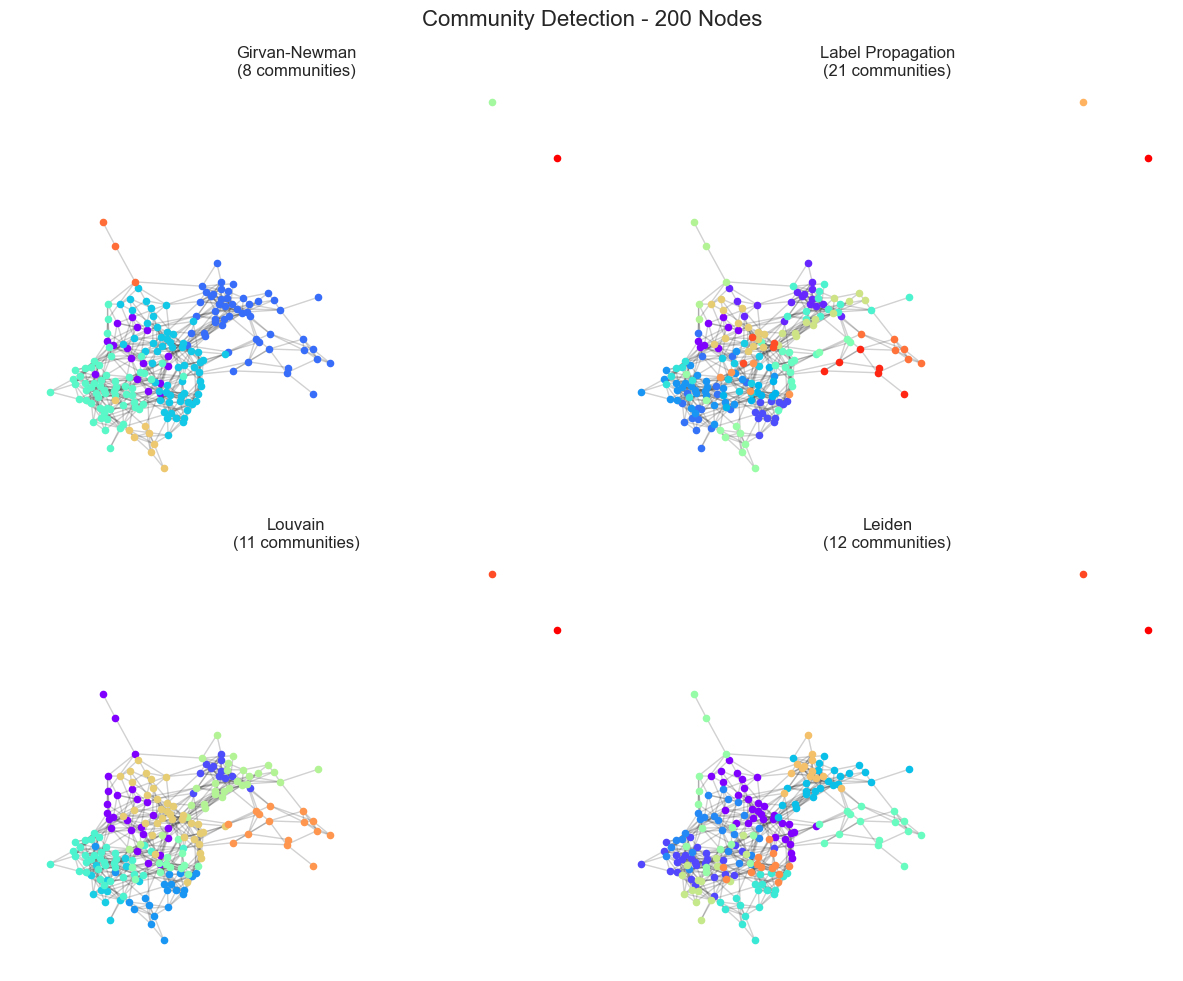

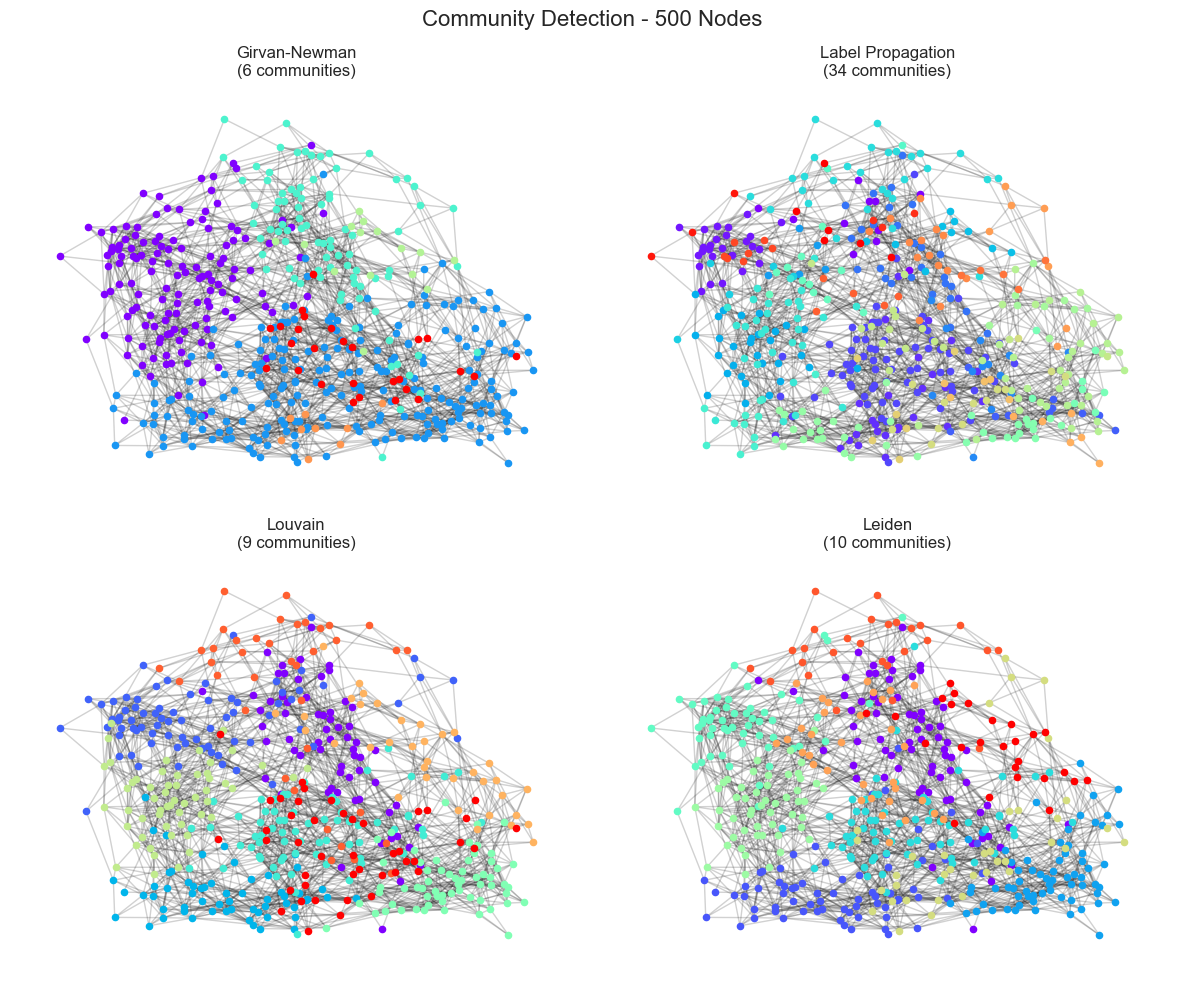

In [25]:
import matplotlib.cm as cm

# Hàm vẽ graph cộng đồng
def draw_community_graph(G, communities, ax, title, pos):
    """
    Vẽ graph cộng đồng

    Parameters
    ----------
    G (graph): Đồ thị đầu vào
    communities (list): Danh sách cộng đồng
    ax (matplotlib axis): Vùng vẽ subplot
    title (str): Tiêu đề graph
    pos (dict): Vị trí các node
    """

    # Tạo màu cho từng cộng đồng
    colors = cm.rainbow(
        np.linspace(0, 1, len(communities))
    )

    # Vẽ node theo từng cộng đồng
    for color, community in zip(colors, communities):

        nx.draw_networkx_nodes(
            G,
            pos,
            nodelist=list(community),
            node_color=[color],
            node_size=20,
            ax=ax
        )

    # Vẽ cạnh của graph
    nx.draw_networkx_edges(
        G,
        pos,
        alpha=0.2,
        ax=ax
    )

    # Tiêu đề graph
    ax.set_title(
        f"{title}\n({len(communities)} communities)"
    )

    ax.axis("off")


# Hàm trực quan hóa tất cả thuật toán
def plot_all_methods(G, title):
    """
    So sánh trực quan các thuật toán phát hiện cộng đồng

    Parameters
    ----------
    G (graph): Đồ thị đầu vào
    title (str): Tiêu đề hình vẽ
    """

    # Chạy tất cả thuật toán
    results = run_all_algorithms(
        G,
        as_dataframe=False
    )

    # Dùng chung layout để dễ so sánh
    pos = nx.spring_layout(
        G,
        seed=42
    )

    # Tạo figure gồm 4 subplot
    fig, axes = plt.subplots(
        2, 2,
        figsize=(12, 10)
    )

    axes = axes.flatten()

    # Vẽ kết quả từng thuật toán
    for ax, result in zip(axes, results):

        draw_community_graph(
            G,
            result["communities"],
            ax,
            result["method"],
            pos
        )

    fig.suptitle(
        title,
        fontsize=16
    )

    plt.tight_layout()
    plt.show()


# Trực quan hóa
plot_all_methods(
    community_graphs[200],
    "Community Detection - 200 Nodes"
)

plot_all_methods(
    community_graphs[500],
    "Community Detection - 500 Nodes"
)


===== THÔNG TIN ĐỒ THỊ =====
Số nút (nodes): 5000
Số cạnh (edges): 36098
Bậc trung bình: 14.44
Mật độ đồ thị: 0.002888
Số thành phần liên thông: 1

===== PHÁT HIỆN CỘNG ĐỒNG (LEIDEN) =====
Số lượng cộng đồng: 14
Thời gian chạy thuật toán: 0.18 giây
Modularity: 0.722
Mật độ trung bình: 0.037

===== PHÂN TÍCH RỦI RO THEO CỘNG ĐỒNG =====
 community  avg_risk  risk_std  size
         5  0.742079  0.098950   379
         3  0.594421  0.095901   433
        13  0.509628  0.105234   155
         0  0.476652  0.110611   657
        12  0.465282  0.106781   175
         8  0.462181  0.076900   293
        10  0.461258  0.090791   262
        11  0.458825  0.063770   233
         4  0.455566  0.119029   399
         1  0.422630  0.107480   541
         9  0.408954  0.074584   268
         7  0.339687  0.091972   309
         2  0.333639  0.084983   525
         6  0.260012  0.080901   371

===== KẾT LUẬN =====
Cộng đồng nguy cơ cao nhất: 5
Điểm rủi ro trung bình: 0.7421

===== TOP SINH VIÊN NGU

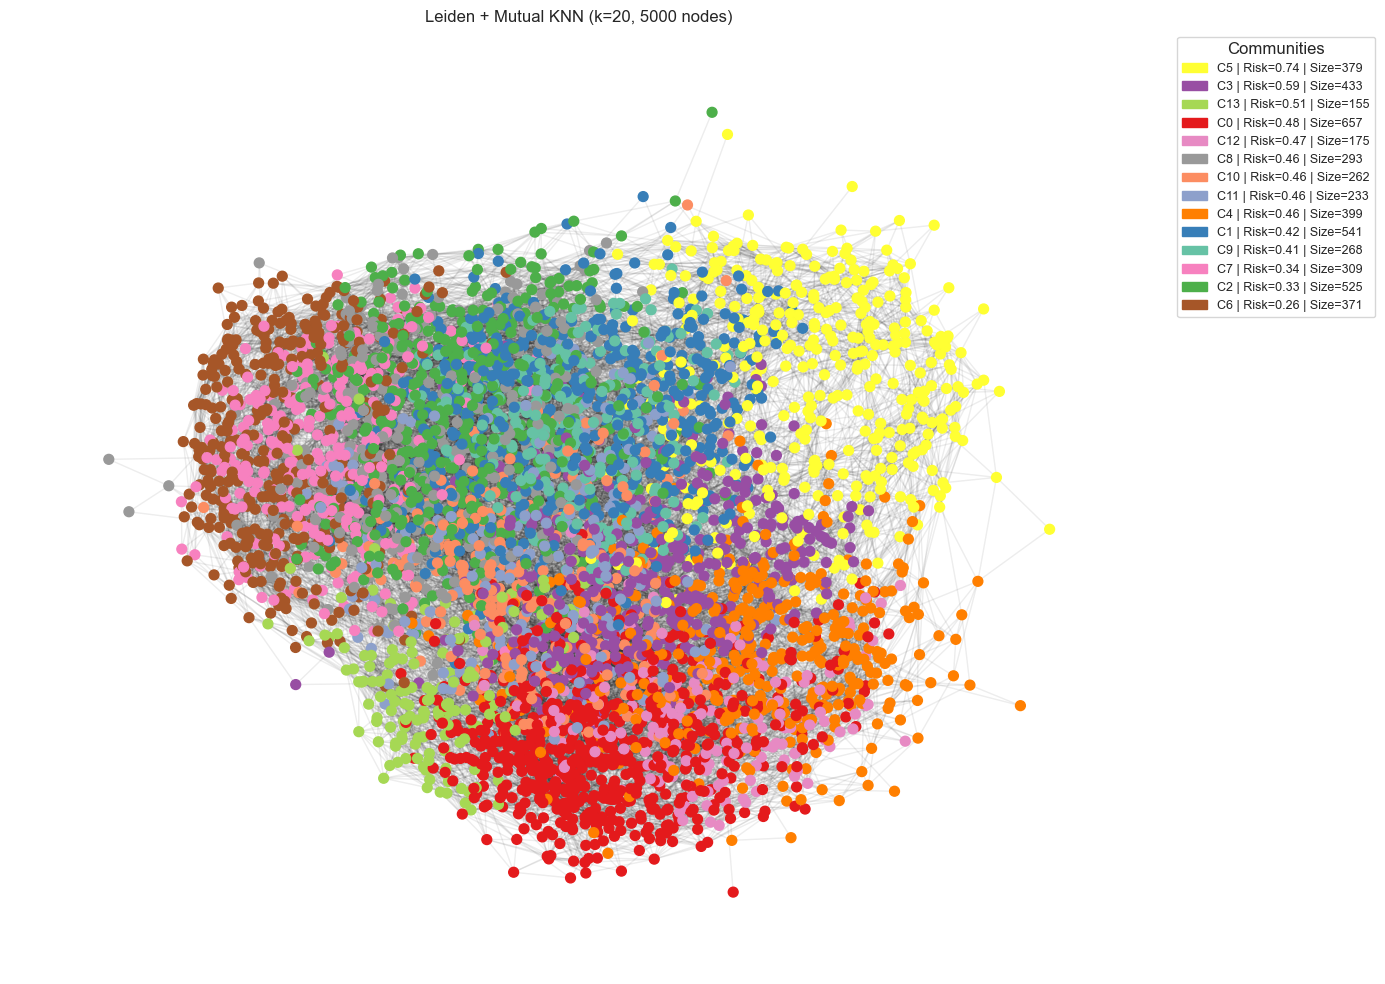

In [26]:
"""
SỬ DỤNG LEIDEN + MUTUAL K-NN ĐỂ PHÁT HIỆN CỘNG ĐỒNG
VÀ NHÓM NGUY CƠ CAO VỀ SỨC KHỎE TÂM THẦN VỚI DATASET 5000 NODES
"""
import seaborn as sns
import matplotlib.patches as mpatches
from sklearn.preprocessing import StandardScaler
sns.set(style="whitegrid")


# Đọc dataset 5000 nodes
df = pd.read_excel(DATASETS[5000])

# Dữ liệu chuẩn hóa Min-Max
X_minmax = load_and_scale(5000)

# Dữ liệu chuẩn hóa Z-score
X_z = StandardScaler().fit_transform(
    df[FEATURES]
)


# Xây dựng Mutual KNN graph
G = build_mutual_graph(
    X_minmax,
    k=20
)

# Thông tin đồ thị
# Số node
num_nodes = G.number_of_nodes()
# Số edge
num_edges = G.number_of_edges()
# Bậc trung bình
avg_degree = np.mean([
    d for _, d in G.degree()
])
# Mật độ graph
graph_density = nx.density(G)
# Số connected component
num_components = nx.number_connected_components(G)

print("\n===== THÔNG TIN ĐỒ THỊ =====")
print(f"Số nút (nodes): {num_nodes}")
print(f"Số cạnh (edges): {num_edges}")
print(f"Bậc trung bình: {avg_degree:.2f}")
print(f"Mật độ đồ thị: {graph_density:.6f}")
print(f"Số thành phần liên thông: {num_components}")

# Hàm phát hiện cộng đồng bằng Leiden
def leiden_comm_full(G):
    """
    Phát hiện cộng đồng bằng giải thuật Leiden.

    Parameters
    ----------
    G : networkx.Graph
        Đồ thị đầu vào.

    Returns
    -------
    dict
        Bao gồm:
        - communities : danh sách các community
        - modularity  : độ đo chất lượng phân cụm
        - runtime     : thời gian chạy
    """

    start = time.time()
    # Chuyển graph từ NetworkX sang iGraph (Leiden hoạt động tốt trên iGraph)
    g = ig.Graph.from_networkx(G)

    # Chạy giải thuật Leiden, sử dụng hàm tối ưu Modularity
    partition = leidenalg.find_partition(
        g,
        leidenalg.ModularityVertexPartition
    )

    communities = [
        set(c)
        for c in partition
    ]

    runtime = time.time() - start

    # Tính chỉ số modularity
    modularity = nx.community.modularity(
        G,
        communities
    )

    return {
        "communities": communities,
        "modularity": modularity,
        "runtime": runtime
    }

# Phát hiện cộng đồng bằng Leiden
leiden_result = leiden_comm_full(G)
communities = leiden_result["communities"]
runtime = leiden_result["runtime"]
modularity = leiden_result["modularity"]
density = np.mean([
    nx.density(G.subgraph(c))
    for c in communities
])

# Kết quả phát hiện cộng đồng
print("\n===== PHÁT HIỆN CỘNG ĐỒNG (LEIDEN) =====")
print(f"Số lượng cộng đồng: {len(communities)}")
print(f"Thời gian chạy thuật toán: {runtime:.2f} giây")
print(f"Modularity: {modularity:.3f}")
print(f"Mật độ trung bình: {density:.3f}")

# Gán Node --> Community
node2comm = {
    node: comm_id
    for comm_id, community in enumerate(communities)
    for node in community
}

df["community"] = (
    df.index
    .map(node2comm)
    .fillna(-1)
    .astype(int)
)


# Tính chỉ số risk_score
z = pd.DataFrame(
    X_z,
    columns=FEATURES
)

# Tính risk score
# - stress cao -> tăng risk
# - ngủ ít -> tăng risk
# - social media nhiều -> tăng risk
# - vận động ít -> tăng risk
# - GPA thấp -> tăng risk
df["risk_score_raw"] = (
    0.30 * z["stress_level"] +
    0.25 * (-z["sleep_duration"]) +
    0.20 * z["social_media_hours"] +
    0.15 * (-z["physical_activity"]) +
    0.10 * (-z["cgpa"])
)

# Chuẩn hóa risk score về [0,1]
df["risk_score"] = (
    MinMaxScaler()
    .fit_transform(
        df[["risk_score_raw"]]
    )
)

# Phân tích rủi ro theo cộng đồng
# Thống kê risk score theo community
risk_by_comm = (
    df.groupby("community")["risk_score"]
    .agg(["mean", "std", "count"])
    .reset_index()
)
# Đổi tên cột
risk_by_comm.columns = [
    "community",
    "avg_risk",
    "risk_std",
    "size"
]
# Sắp xếp theo risk giảm dần
risk_by_comm = (
    risk_by_comm
    .sort_values(
        "avg_risk",
        ascending=False
    )
)

print("\n===== PHÂN TÍCH RỦI RO THEO CỘNG ĐỒNG =====")
print(risk_by_comm.to_string(index=False))


# Kết quả
top_comm = int(
    risk_by_comm.iloc[0]["community"]
)

top_risk = (
    risk_by_comm.iloc[0]["avg_risk"]
)

high_risk_students = df[
    df["community"] == top_comm
]

print("\n===== KẾT LUẬN =====")
print(f"Cộng đồng nguy cơ cao nhất: {top_comm}")
print(f"Điểm rủi ro trung bình: {top_risk:.4f}")


# Top sinh viên có nguy cơ cao
print("\n===== TOP SINH VIÊN NGUY CƠ CAO=====")
print(high_risk_students.head().to_string(index=False))

# Hồ sơ các cộng đồng
profile = (
    df.groupby("community")[
        FEATURES + ["risk_score"]
    ]
    .mean()
)

profile["size"] = (
    df["community"]
    .value_counts()
)

profile = (
    profile
    .sort_values(
        "risk_score",
        ascending=False
    )
    .reset_index()
)
print("\n===== COMMUNITY PROFILE =====")
print(profile.to_string(index=False))

# Trực quan
plt.figure(figsize=(14, 10))
pos = nx.spring_layout(G, seed=42)

# Bảng màu node
colors = [
    "#e41a1c", "#377eb8", "#4daf4a", "#984ea3", "#ff7f00",
    "#ffff33", "#a65628", "#f781bf", "#999999", "#66c2a5",
    "#fc8d62", "#8da0cb", "#e78ac3", "#a6d854", "#ffd92f",
    "#e5c494", "#b3b3b3", "#1f78b4", "#b2df8a", "#fb9a99"
]

node_colors = [
    colors[c % len(colors)]
    for c in df["community"]
]

nx.draw_networkx_nodes( G, pos, node_size=50, node_color=node_colors)
nx.draw_networkx_edges(G, pos, alpha=0.08, width=1)

plt.title("Leiden + Mutual KNN (k=20, 5000 nodes)")
plt.axis("off")


# LEGEND
legend_patches = []

for _, row in risk_by_comm.iterrows():

    comm_id = int(row["community"])

    color = colors[
        comm_id % len(colors)
    ]

    label = (
        f"C{comm_id} | "
        f"Risk={row['avg_risk']:.2f} | "
        f"Size={int(row['size'])}"
    )

    legend_patches.append(
        mpatches.Patch(
            color=color,
            label=label
        )
    )

plt.legend(
    handles=legend_patches,
    loc='upper left',
    bbox_to_anchor=(1.02, 1),
    fontsize=9,
    frameon=True,
    title="Communities"
)

plt.tight_layout()

plt.show()